In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load preprocessing_train.parquet
df_train = pd.read_parquet('preprocessing_train.parquet')

# Load preprocessing_test.parquet
df_test = pd.read_parquet('preprocessing_test.parquet')

print("preprocessing_train.parquet head:")
display(df_train.head())

print("preprocessing_test.parquet head:")
display(df_test.head())

preprocessing_train.parquet head:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,originalConstructionDate,originalNBDate,...,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE,coord_x,coord_y,coord_z
0,-1.095671,-0.647591,-0.658311,-0.096999,0.287760,0.648721,-0.544076,-0.538643,0.919092,0.518824,...,-1.625521,True,False,True,False,False,False,1.108277,1.292637,1.544664
1,-0.164325,-0.647591,-0.726156,-0.096999,-0.840678,-1.781678,-0.656198,-0.538643,1.036053,0.736138,...,-1.594654,False,False,False,False,False,True,0.250586,0.828012,1.463924
2,-1.095671,-0.647591,-0.927913,-0.096999,-0.858404,0.201146,-0.855267,-0.538643,0.482422,0.730122,...,-1.576934,False,False,True,False,True,False,0.600415,-0.596844,-0.660945
3,-0.164325,-0.647591,-0.570775,-0.096999,-0.704245,-1.781678,-0.476393,-0.538643,0.943158,0.892399,...,-1.663820,False,False,True,False,False,True,-0.788061,0.038554,0.431639
4,-1.095671,-0.647591,-0.655672,-0.096999,0.287760,0.648721,-0.541045,-0.538643,-0.756333,0.369141,...,-1.472899,False,True,True,False,True,False,-2.486378,1.213791,0.378731


preprocessing_test.parquet head:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,originalConstructionDate,originalNBDate,...,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE,coord_x,coord_y,coord_z
0,-0.164325,-0.647591,1.113705,-0.096999,0.287760,-1.781678,1.415972,-0.538643,0.712322,0.407308,...,-1.561500,False,False,False,False,False,True,0.674881,-0.865654,-1.212934
1,-0.164325,-0.647591,-0.688776,-0.096999,0.131956,0.368379,-0.612845,-0.538643,-0.874349,0.804047,...,-1.591224,False,True,True,False,False,True,0.881876,0.230503,0.431639
2,-0.164325,-0.647591,0.104164,-0.096999,0.287760,0.648721,0.293340,-0.538643,-0.004410,0.554386,...,-1.507768,True,True,False,False,False,True,0.939092,0.471319,0.710547
3,-0.164325,-0.647591,-0.641187,-0.096999,0.287760,-1.781678,-0.557742,-0.538643,-1.055935,0.439512,...,-1.638097,True,True,True,False,False,True,0.801729,0.102064,0.307892
4,-1.095671,-0.647591,-0.723475,-0.096999,0.287760,0.115560,-0.619012,-0.538643,0.753242,0.398288,...,-1.540350,False,False,False,False,True,False,0.985632,1.151590,1.480121


In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare features and target
X = df_train.drop(columns=['policyCost'])
y = df_train['policyCost']

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")

Features: 20
Training samples: 284517


### 1. Ridge Regression (Tuned Linear Model)
Ridge regression adds a penalty to coefficients to prevent overfitting.

In [3]:
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_search = RandomizedSearchCV(Ridge(), ridge_params, n_iter=4, cv=3, scoring='neg_mean_squared_error', random_state=42)
ridge_search.fit(X_train, y_train)

best_ridge = ridge_search.best_estimator_
ridge_preds = best_ridge.predict(X_val)

print(f"Best Alpha: {ridge_search.best_params_}")
print(f"Ridge MSE: {mean_squared_error(y_val, ridge_preds):.4f}")
print(f"Ridge R2: {r2_score(y_val, ridge_preds):.4f}")

Best Alpha: {'alpha': 1.0}
Ridge MSE: 0.0009
Ridge R2: 0.9991


### 2. XGBoost (Tuned)
A powerful gradient boosting framework.

In [4]:
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 6]
}
xgb_search = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42), xgb_params, n_iter=4, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
xgb_preds = best_xgb.predict(X_val)

print(f"Best XGB Params: {xgb_search.best_params_}")
print(f"XGB MSE: {mean_squared_error(y_val, xgb_preds):.4f}")
print(f"XGB R2: {r2_score(y_val, xgb_preds):.4f}")

Best XGB Params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
XGB MSE: 0.0085
XGB R2: 0.9915


### Test Set Evaluation
We will now prepare the test features and evaluate our models to see which one generalizes best.

In [5]:
# Prepare test features and target
X_test = df_test.drop(columns=['policyCost'])
y_test = df_test['policyCost']

# Ridge Predictions
ridge_test_preds = best_ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_test_preds)
ridge_r2 = r2_score(y_test, ridge_test_preds)

# XGBoost Predictions
xgb_test_preds = best_xgb.predict(X_test)
xgb_mse = mean_squared_error(y_test, xgb_test_preds)
xgb_r2 = r2_score(y_test, xgb_test_preds)

# Summary Results
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'XGBoost'],
    'Test MSE': [ridge_mse, xgb_mse],
    'Test R2': [ridge_r2, xgb_r2]
})

display(results)

,Model,Test MSE,Test R2
0,Ridge Regression,0.000875,0.999120
1,XGBoost,0.008653,0.991292


### Conclusion

After evaluating our models on the held-out test set, we have a clear winner:

*   **Winner: Ridge Regression** (MSE: 0.000875, R²: 0.999120)
*   **Runner-up: XGBoost** (MSE: 0.008653, R²: 0.991292)

The Ridge Regression model achieved an exceptionally high R² score, suggesting that the underlying relationship between policy features and cost is highly linear. This model provides more accurate predictions and is also more computationally efficient than the gradient-boosted ensemble in this instance.

### Feature Importance: Ridge Regression
Since the Ridge model performs best, we can look at the magnitude of its coefficients to understand which features drive the `policyCost`.

/tmp/ipykernel_16993/3499159183.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='coolwarm')


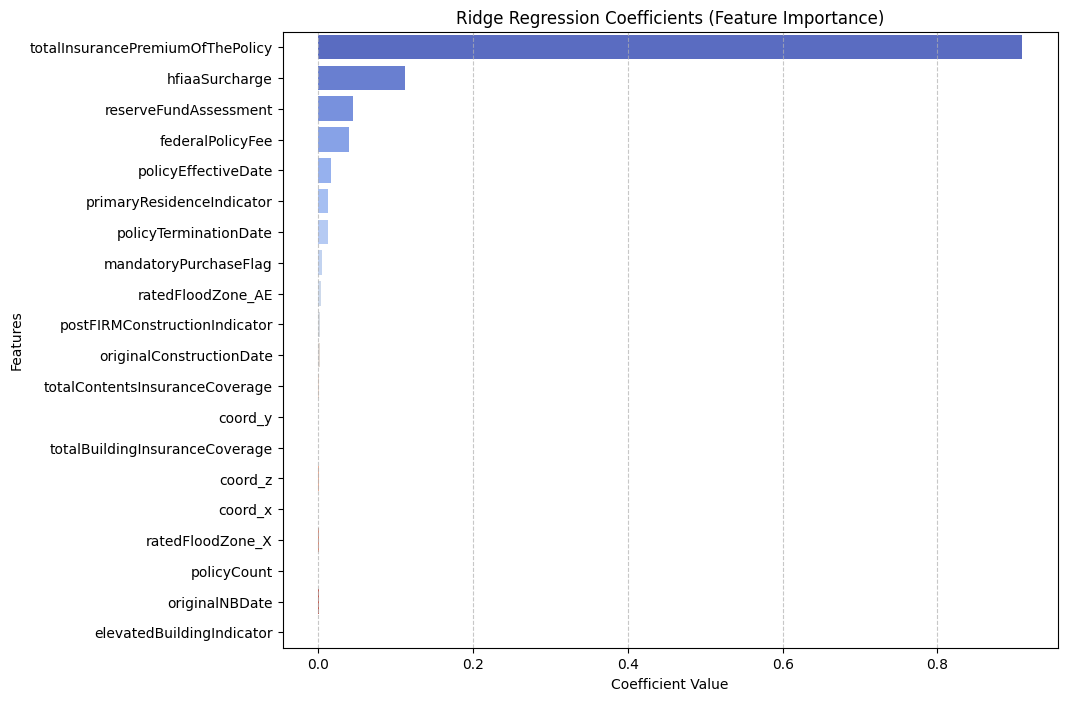

,Feature,Coefficient
5,totalInsurancePremiumOfThePolicy,0.909678
1,hfiaaSurcharge,0.112569
6,reserveFundAssessment,0.044478
0,federalPolicyFee,0.039761
9,policyEffectiveDate,0.016122
13,primaryResidenceIndicator,0.013051
10,policyTerminationDate,0.012222
14,mandatoryPurchaseFlag,0.005049
16,ratedFloodZone_AE,0.003127
12,postFIRMConstructionIndicator,0.001476


In [9]:
# Get coefficients from the best Ridge model
feature_names = X.columns
coefficients = best_ridge.coef_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values(by='AbsCoefficient', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='coolwarm')
plt.title('Ridge Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(importance_df[['Feature', 'Coefficient']])

### Exploring Non-Linear Models: Random Forest & LightGBM

In [7]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# 3. Tuned LightGBM
lgb_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500],
    'num_leaves': [31, 63]
}
lgb_search = RandomizedSearchCV(lgb.LGBMRegressor(random_state=42), lgb_grid, n_iter=3, cv=3, n_jobs=-1, random_state=42)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_
lgb_test_preds = best_lgb.predict(X_test)

# Update Summary Results
new_results = pd.DataFrame({
    'Model': ['LightGBM (Tuned)'],
    'Test MSE': [mean_squared_error(y_test, lgb_test_preds)],
    'Test R2': [r2_score(y_test, lgb_test_preds)]
})

final_summary = pd.concat([results, new_results], ignore_index=True)
display(final_summary.sort_values(by='Test MSE'))

print(f"Best LGBM Params: {lgb_search.best_params_}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3041
[LightGBM] [Info] Number of data points in the train set: 284517, number of used features: 20
[LightGBM] [Info] Start training from score -0.000265


,Model,Test MSE,Test R2
0,Ridge Regression,0.000875,0.999120
2,LightGBM (Tuned),0.005241,0.994726
1,XGBoost,0.008653,0.991292


Best LGBM Params: {'num_leaves': 63, 'n_estimators': 100, 'learning_rate': 0.1}


### 4. Lasso Regression and MLPRegressor
Let's add a sparsity-inducing linear model and a basic Neural Network to our comparison.

In [8]:
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# 4. Tuned Lasso Regression
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1]}
lasso_search = RandomizedSearchCV(Lasso(max_iter=2000), lasso_params, n_iter=4, cv=3, random_state=42)
lasso_search.fit(X_train, y_train)
best_lasso = lasso_search.best_estimator_
lasso_test_preds = best_lasso.predict(X_test)

# 5. Tuned MLPRegressor (Neural Network)
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'alpha': [0.0001, 0.05],
    'learning_rate_init': [0.001, 0.01]
}
mlp_search = RandomizedSearchCV(MLPRegressor(max_iter=500, random_state=42), mlp_params, n_iter=3, cv=3, random_state=42)
mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_
mlp_test_preds = best_mlp.predict(X_test)

# Append to final results
extended_results = pd.DataFrame({
    'Model': ['Lasso (Tuned)', 'MLPRegressor (Tuned)'],
    'Test MSE': [mean_squared_error(y_test, lasso_test_preds), mean_squared_error(y_test, mlp_test_preds)],
    'Test R2': [r2_score(y_test, lasso_test_preds), r2_score(y_test, mlp_test_preds)]
})

final_summary_v2 = pd.concat([final_summary, extended_results], ignore_index=True)
display(final_summary_v2.sort_values(by='Test MSE'))

print(f"Best Lasso Alpha: {lasso_search.best_params_}")
print(f"Best MLP Params: {mlp_search.best_params_}")

,Model,Test MSE,Test R2
0,Ridge Regression,0.000875,0.999120
3,Lasso (Tuned),0.000876,0.999119
4,MLPRegressor (Tuned),0.001806,0.998183
2,LightGBM (Tuned),0.005241,0.994726
1,XGBoost,0.008653,0.991292


Best Lasso Alpha: {'alpha': 0.0001}
Best MLP Params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
